<a href="https://colab.research.google.com/github/LanqingDu/AdvancedBusinessAnalytics/blob/main/NB_7_Recurrent_Neural_Networks.ipynb" target="_blank">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **RNN**



> **Instructor:** Dr. Lanqing Du  
> **Acknowledgement:** Based on [Python manuals](https://docs.python.org/3/), [Automate the Boring Stuff with Python, 2nd Edition: Practical Programming for Total Beginners](https://automatetheboringstuff.com/2e/), [Laurence Moroney](https://github.com/lmoroney) and other data Science online sources.    
> **Objective:** Introduction to recurrent neural networks.  
> **Instructions:** You can preview the **Table of Contents** from the side bar.

> **Disclaimer**: This notebook is prepared for instructional purposes. Some code blocks may intentionally contain errors to support the learning objectives.

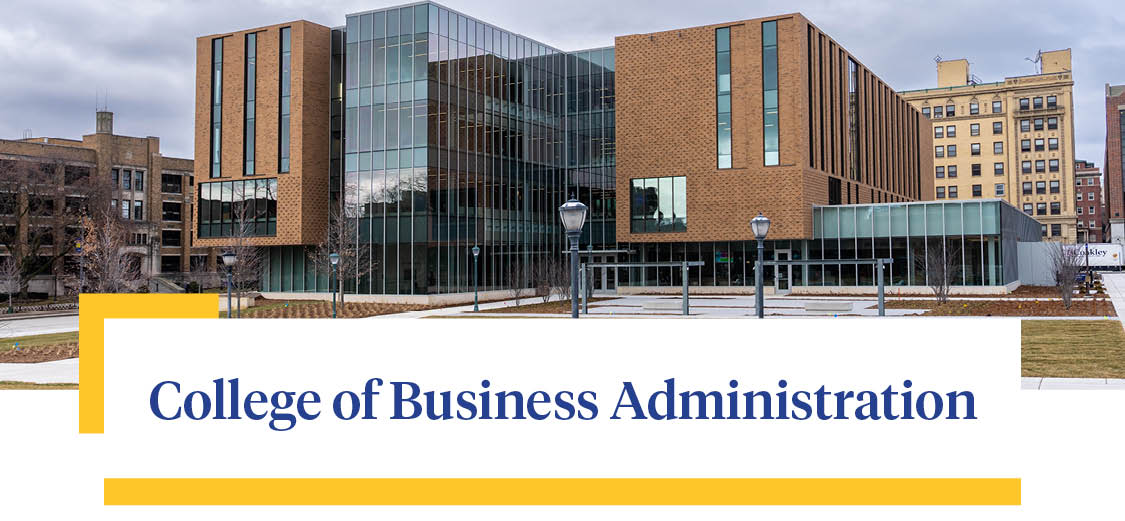
---

---

## [0. Agenda ](#Intro)

<h2>Recurrent Neural Network (RNN)</h2>

- <h3>What Is It?</h3>
  <ul>
    <li><strong>Architecture:</strong> Recurrent Neural Network (RNN)</li>
    <li><strong>Purpose:</strong> Designed for sequential data</li>
    <li><strong>Core Idea:</strong> Maintains a hidden state
      (<code>h<sub>t</sub> = f(x<sub>t</sub>, h<sub>t-1</sub>)</code>) to retain past information
    </li>
  </ul>

- <h3>Why Use It?</h3>
  <ul>
    <li>Captures order and context in sequences</li>
    <li>Shares weights across time steps</li>
    <li>Models dependencies between inputs</li>
  </ul>

- <h3>Why for Text Analytics?</h3>
  <ul>
  <li>Text is sequential (word order matters)</li>
  <li>Meaning depends on context (e.g., “not good”)</li>
  <li>Useful for sentiment analysis, classification, and language modeling</li>
  </ul>


---

## [1. Text Data](#data)


In [ ]:
# step 0: include libraries

import json
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import numpy as np
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
import string

In [ ]:
# step 1: define stop words

stopwords = ["a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are", "as", "at",
             "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "could", "did", "do",
             "does", "doing", "down", "during", "each", "few", "for", "from", "further", "had", "has", "have", "having",
             "he", "hed", "hes", "her", "here", "heres", "hers", "herself", "him", "himself", "his", "how",
             "hows", "i", "id", "ill", "im", "ive", "if", "in", "into", "is", "it", "its", "itself",
             "lets", "me", "more", "most", "my", "myself", "nor", "of", "on", "once", "only", "or", "other", "ought",
             "our", "ours", "ourselves", "out", "over", "own", "same", "she", "shed", "shell", "shes", "should",
             "so", "some", "such", "than", "that", "thats", "the", "their", "theirs", "them", "themselves", "then",
             "there", "theres", "these", "they", "theyd", "theyll", "theyre", "theyve", "this", "those", "through",
             "to", "too", "under", "until", "up", "very", "was", "we", "wed", "well", "were", "weve", "were",
             "what", "whats", "when", "whens", "where", "wheres", "which", "while", "who", "whos", "whom", "why",
             "whys", "with", "would", "you", "youd", "youll", "youre", "youve", "your", "yours", "yourself",
             "yourselves"]

table = str.maketrans('', '', string.punctuation)

### 1.0 Load in data

In [ ]:
# step 2: download the data

!wget https://raw.githubusercontent.com/ashwaniYDV/sarcasm-detection-tensorflow/main/sarcasm.json

--2026-03-03 22:47:32--  https://raw.githubusercontent.com/ashwaniYDV/sarcasm-detection-tensorflow/main/sarcasm.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5616834 (5.4M) [text/plain]
Saving to: ‘sarcasm.json’

sarcasm.json        100%[===================>]   5.36M  --.-KB/s    in 0.02s   

2026-03-03 22:47:33 (307 MB/s) - ‘sarcasm.json’ saved [5616834/5616834]



In [ ]:
# step 3: load the data

with open("sarcasm.json", 'r') as f:
    dataset = json.load(f)

In [ ]:
# step 4: preview the data

dataset[0]

{'article_link': 'https://www.huffingtonpost.com/entry/versace-black-code_us_5861fbefe4b0de3a08f600d5',
 'headline': "former versace store clerk sues over secret 'black code' for minority shoppers",
 'is_sarcastic': 0}

In [ ]:
# step 5: data preprocessing

def clean_document(document):
  document = document.lower()
  document = document.replace(',', ' , ')
  document = document.replace('.', ' . ')
  document = document.replace('-', ' - ')
  document = document.replace('/', ' / ')
  soup = BeautifulSoup(document)
  document = soup.get_text()
  words = document.split()
  filtered_document = ''
  for word in words:
    word = word.translate(table)
    if word not in stopwords:
      filtered_document = filtered_document + word + ' '
  return filtered_document

In [ ]:
# step 6: seperate texts and labels

documents = []
labels = []
urls = []

for item in dataset:
  labels.append(item['is_sarcastic'])
  urls.append(item['article_link'])
  document = clean_document(item['headline'])
  documents.append(document)

### 1.1 Vectorization

In [ ]:
# step 6: seperate texts and labels

vocab_size = 2000
embedding_dim = 16
max_length = 100
trunc_type='post'
padding_type='post'
oov_tok = "<OOV>"
training_size = 23000

In [ ]:
# step 7: train-val split

training_docs, validation_docs, training_labels, validation_labels = train_test_split(
    documents,
    labels,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


In [ ]:
# step 8: tokenization

# ======================TODO BELOW========================
# fill in the <...>


# tokenize on the training_docs with the specified vocab size and oov token


tokenizer = Tokenizer(<...>, <...>)
tokenizer.fit_on_texts(<...>)
word_index = tokenizer.word_index



# ======================TODO ABOVE========================




In [ ]:
# step 9: tokenize to sequence with padding (training docs)

# ======================TODO BELOW========================
# fill in the <...>


# generate the tokenized training sequence

training_sequences = tokenizer.texts_to_sequences(<...>)


# generate the padded sequence

training_padded = pad_sequences(<...>, maxlen=<...>,
                                padding=<...>, truncating=<...>)


# ======================TODO ABOVE========================

In [ ]:
# step 10: tokenize to sequence with padding (validation docs)

validation_sequences = tokenizer.texts_to_sequences(validation_docs)
validation_padded = pad_sequences(validation_sequences, maxlen=max_length,
                                padding=padding_type, truncating=trunc_type)

In [ ]:
# step 11: convert to numpy array

training_padded = np.array(training_padded)
training_labels = np.array(training_labels)
validation_padded = np.array(validation_padded)
validation_labels = np.array(validation_labels)

---

## [2. Unfolded Recurrent Neural Network](#Intro)



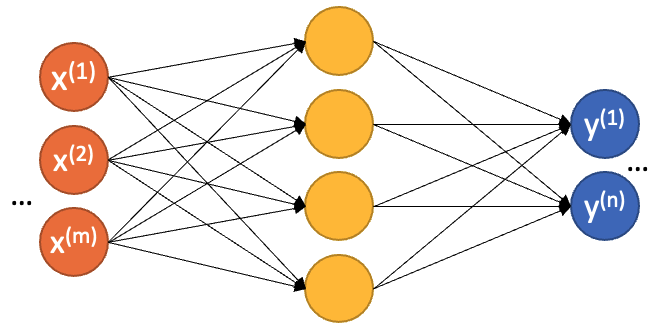

Let's represent the hidden layers by a single box (a black-box!).

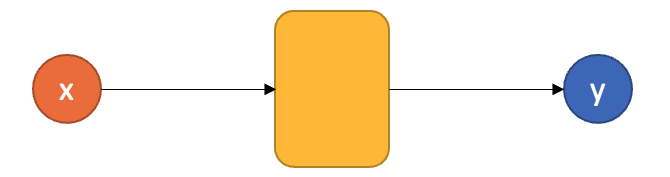

Let's rotate the figure and repeat it for each time step.

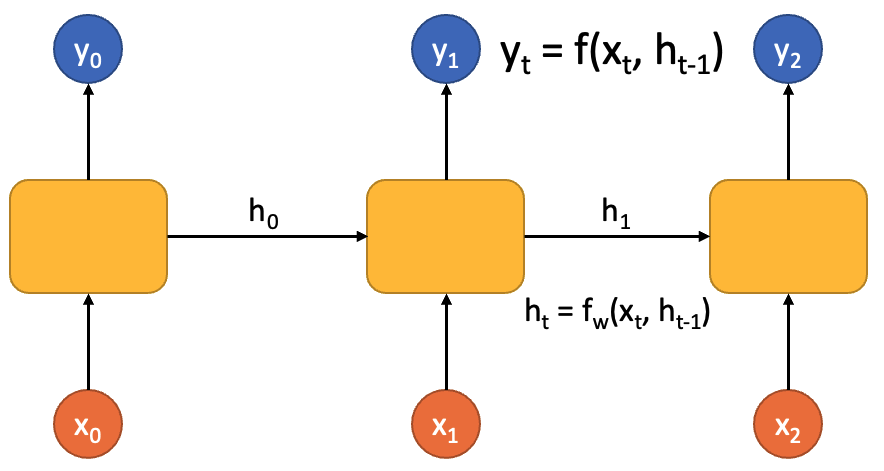

<h2>Recurrent Neural Network (RNN) Architecture</h2>

<h3>What Is This Architecture?</h3>
<ul>
  <li><strong>Name:</strong> Recurrent Neural Network (RNN)</li>
  <li><strong>Core Idea:</strong> Processes sequential data one time step at a time.</li>
  <li><strong>Key Property:</strong> Maintains a hidden state (<code>h<sub>t</sub></code>) that carries information from previous time steps.</li>
  <li><strong>Mathematical Form:</strong>
    <br>
    <code>h<sub>t</sub> = f(x<sub>t</sub>, h<sub>t-1</sub>)</code>
    <br>
    <code>y<sub>t</sub> = g(h<sub>t</sub>)</code>
  </li>
</ul>

<h3>Why Do We Use This Architecture?</h3>
<ul>
  <li><strong>Handles Sequential Data:</strong> Designed for ordered inputs such as text, speech, and time series.</li>
  <li><strong>Captures Context:</strong> Remembers previous inputs through the hidden state.</li>
  <li><strong>Weight Sharing:</strong> Uses the same parameters at every time step, reducing model complexity.</li>
  <li><strong>Flexible Output:</strong> Can produce outputs at every time step or only at the final step.</li>
</ul>

<h3>Why Is It Needed for Text Analytics?</h3>
<ul>
  <li><strong>Text Is Sequential:</strong> The meaning of a word depends on previous words.</li>
  <li><strong>Context Matters:</strong> Example: “not good” vs. “good”.</li>
  <li><strong>Captures Dependencies:</strong> Models relationships across words in a sentence.</li>
  <li><strong>Suitable for NLP Tasks:</strong>
    <ul>
      <li>Sentiment Analysis</li>
      <li>Text Classification</li>
      <li>Language Modeling</li>
      <li>Machine Translation</li>
    </ul>
  </li>
</ul>

<h3>Key Insight</h3>
<p>
Unlike traditional feedforward neural networks, RNNs incorporate memory,
allowing them to learn patterns across sequences rather than treating inputs independently.
This makes them particularly powerful for natural language processing tasks.
</p>

### 2.0 Model

In [ ]:
# step 12: model



# ======================TODO BELOW========================
# fill in the <...>


# Create a sequential neural network model
model1 = tf.keras.Sequential([

    # Embedding layer:
    # Converts word indices into dense vector representations
    # Output shape: (batch_size, sequence_length, embedding_dim)
    tf.keras.layers.Embedding(<...>, <...>),

    # Bidirectional LSTM layer:
    # Processes the sequence forward and backward
    # Captures context from both past and future words
    tf.keras.layers.Bidirectional(<...>),

    # Dense hidden layer:
    # Learns higher-level features from LSTM output
    # Uses ReLU activation and L2 regularization to reduce overfitting
    <...>

    # Output layer:
    # Single neuron with sigmoid activation for binary classification
    # Outputs probability between 0 and 1
    <...>
])



# ======================TODO ABOVE========================



model1.compile(loss = 'binary_crossentropy',
               optimizer = 'adam',
               metrics = ['accuracy'])

model1.summary()

FYI: Inside each LSTM cell may look like the following figure.

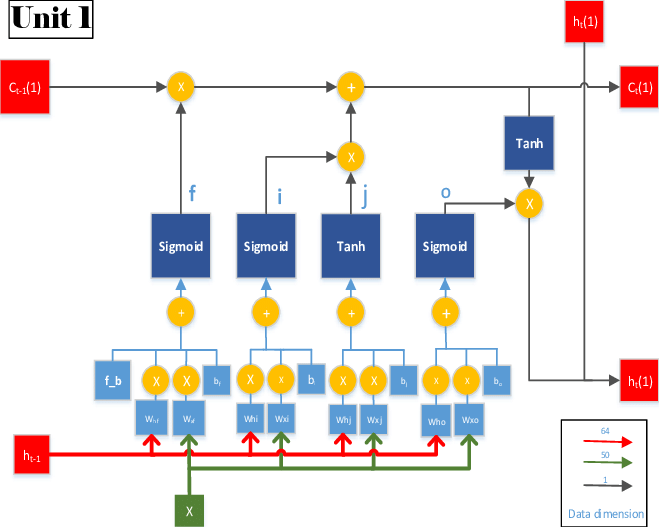

Credit: Wen, S., Wei, H., Yang, Y., Guo, Z., Zeng, Z, 2019 "Memristive LSTM Network for Sentiment Analysis," IEEE TRANSACTIONS ON SYSTEMS MAN AND CYBERNETICS: SYSTEMS

In [ ]:
# step 13: model training


# ======================TODO BELOW========================
# fill in the <...>


history1 = model1.fit(<...>, <...>, epochs=20, validation_data=(<...>, <...>))


# ======================TODO ABOVE========================


# To reduce the wait time in the classroom, we run the model with only 20 epochs.
# But we need 100-150 epochs to better investigate the learning curves.

Epoch 1/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.6287 - loss: 1.5806 - val_accuracy: 0.7662 - val_loss: 0.5062
Epoch 2/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7947 - loss: 0.4591 - val_accuracy: 0.7635 - val_loss: 0.4865
Epoch 3/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8120 - loss: 0.4236 - val_accuracy: 0.7919 - val_loss: 0.4691
Epoch 4/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8269 - loss: 0.3934 - val_accuracy: 0.7929 - val_loss: 0.4623
Epoch 5/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8382 - loss: 0.3698 - val_accuracy: 0.7948 - val_loss: 0.4557
Epoch 6/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8462 - loss: 0.3542 - val_accuracy: 0.7889 - val_loss: 0.4700
Epoch 7/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8550 - loss: 0.3431 - val_accuracy: 0.7800 - val_loss: 0.4644
Epoch 8/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8604 - loss: 0.3312 - 

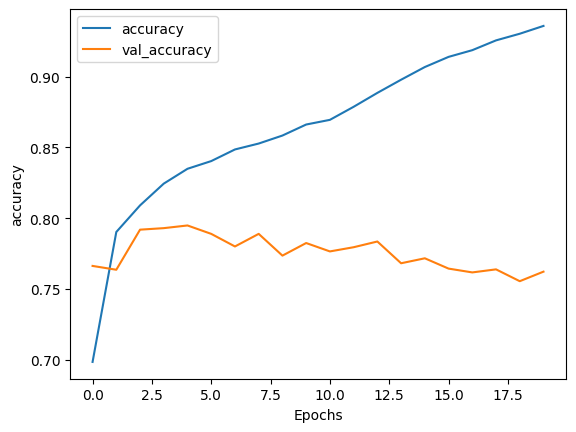

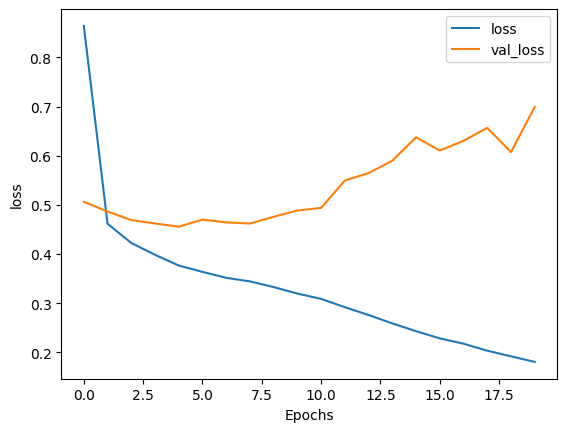

In [ ]:
# step 13: model performance visualization

def plot_graphs(history, set_name):
  plt.plot(history.history[set_name])
  plt.plot(history.history['val_' + set_name])
  plt.xlabel("Epochs")
  plt.ylabel(set_name)
  plt.legend([set_name, 'val_' + set_name])
  plt.show()

plot_graphs(history1, "accuracy")
plot_graphs(history1, "loss")

### 2.1 Revised model

In [ ]:
# step 14: revised model with dropouts

model2 = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(100, return_sequences=True, dropout=0.2)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(100, dropout=0.2)),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model2.compile(loss = 'binary_crossentropy',
               optimizer = tf.keras.optimizers.Adam(learning_rate=0.000008),
               metrics = ['accuracy'])

model2.summary()

In [ ]:
# step 15: train the revised model

history2 = model2.fit(training_padded, training_labels, epochs=20, validation_data=(validation_padded, validation_labels))

# To reduce the wait time in the classroom, we run the model with only 20 epochs.
# But we need 100-150 epochs to better investigate the learning curves.

Epoch 1/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.5469 - loss: 0.6911 - val_accuracy: 0.5700 - val_loss: 0.6831
Epoch 2/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.5610 - loss: 0.6847 - val_accuracy: 0.5700 - val_loss: 0.6813
Epoch 3/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5599 - loss: 0.6839 - val_accuracy: 0.5700 - val_loss: 0.6797
Epoch 4/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.5552 - loss: 0.6827 - val_accuracy: 0.5697 - val_loss: 0.6756
Epoch 5/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.5651 - loss: 0.6758 - val_accuracy: 0.5991 - val_loss: 0.6637
Epoch 6/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.6050 - loss: 0.6603 - val_accuracy: 0.6212 - val_loss: 0.6479
Epoch 7/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6250 - loss: 0.6491 - val_accuracy: 0.6344 - val_loss: 0.6389
Epoch 8/20
719/719 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.6321 - loss: 0.6384 - 

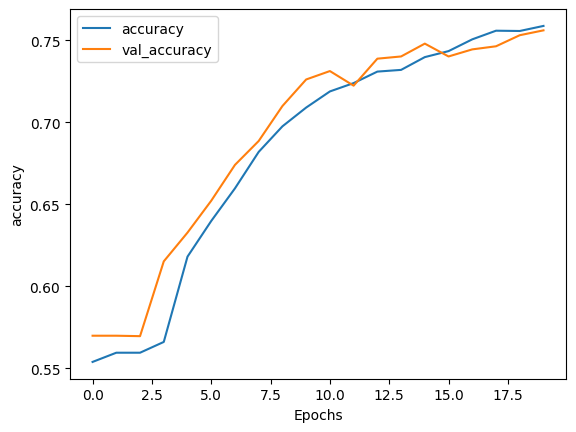

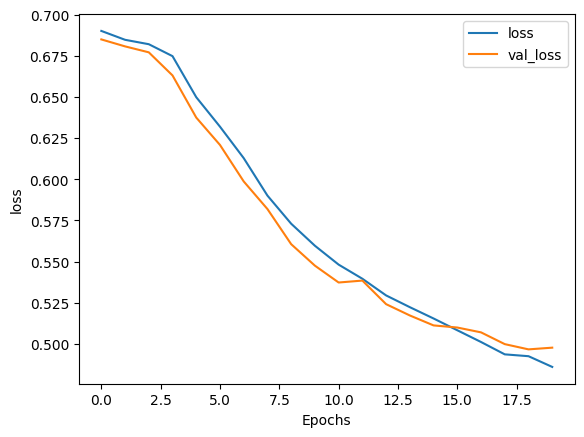

In [ ]:
# step 16: performance visualization

plot_graphs(history2, "accuracy")
plot_graphs(history2, "loss")

### 2.2 Model adoption

In [ ]:
# step 17: test data

test_sentences = ["It Was, For, Uh, Medical Reasons, Says Doctor To Boris Johnson, Explaining Why They Had To Give Him Haircut",
                  "It's a beautiful sunny day",
                  "I lived in Ireland, so in High School they made me learn to speak and write in Gaelic",
                  "Census Foot Soldiers Swarm Neighborhoods, Kick Down Doors To Tally Household Sizes"]

In [ ]:
# step 18: test data tokenization


# ======================TODO BELOW========================
# fill in the <...>

# test data

test_sequences = <...>(<...>)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)


# ======================TODO ABOVE========================

In [ ]:
# step 19: making prediction use model1


# ======================TODO BELOW========================
# fill in the <...>

# making prediciton


predictions1 = model1.<...>(<...>)
predictions1


# ======================TODO ABOVE========================

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


array([[0.01204841],
       [0.14513977],
       [0.9847468 ],
       [0.85729206]], dtype=float32)

In [ ]:
# step 20: making prediction use model2

predictions2 = model2.predict(test_padded)
predictions2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step


array([[0.19594064],
       [0.31632146],
       [0.8379002 ],
       [0.8582641 ]], dtype=float32)

### 2.2 Embeddings

In [ ]:
# step 21: embeddings for model1 and model2


# ======================TODO BELOW========================
# fill in the <...>

# return the embeddings

weights1 = model1.layers[0].get_weights()<...>
weights2 = model2.layers[0].get_weights()<...>


# ======================TODO ABOVE========================

In [ ]:
# step 22: create reverse word index series

reverse_word_index = {}

for (key, value) in word_index.items():
  reverse_word_index[value] = key

# Alternative code:
# reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

In [ ]:
# step 22: print the embeddings from model1

import pandas as pd

df1 = pd.DataFrame(weights1)
df1['word'] = [reverse_word_index[word_num] for word_num in range(1, vocab_size+1)]
df1 = df1.set_index('word')
df1

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
word,,,,,,,,,,,,,,,,
<OOV>,-0.112412,-0.040607,0.017890,0.012547,-0.057227,-0.066112,0.052867,-0.061917,-0.021586,0.029674,0.041512,0.026304,0.022183,-0.015652,-0.051005,-0.108130
new,-0.043410,-0.038064,0.093022,-0.027308,0.046611,0.014720,-0.041233,0.003457,-0.021256,-0.060785,0.028633,-0.068622,-0.001155,0.029419,0.018161,0.024376
trump,0.033078,0.181135,-0.030964,0.134044,-0.114019,-0.037585,0.025660,0.023962,-0.083760,-0.015667,0.092277,-0.031040,0.060284,-0.057177,-0.044908,-0.072921
man,-0.162384,-0.155571,-0.304982,0.119880,0.142202,-0.043895,-0.197880,-0.024214,0.197523,0.061553,-0.060913,0.246372,-0.245656,0.227486,0.155524,-0.183745
not,0.154494,0.141619,0.271095,0.079452,-0.125885,0.134451,0.285673,0.109246,-0.286663,-0.130856,0.238723,-0.221481,0.286842,-0.172710,-0.272864,0.037089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
laid,-0.024629,-0.142554,-0.248256,-0.039252,0.096278,-0.170120,-0.188419,0.030158,0.132565,0.164929,-0.039730,0.213957,-0.137213,0.120604,0.121688,-0.009332
add,0.001282,0.106151,0.181815,0.227953,0.009323,0.002873,0.054937,-0.091829,0.113285,0.036623,-0.001445,-0.134969,-0.043405,-0.112699,0.089657,0.079504
communities,0.205883,0.129144,0.286104,0.257538,-0.221382,0.287609,0.040879,0.179170,0.086368,-0.169406,0.083562,-0.292818,-0.112380,-0.213137,0.065364,0.301090


In [ ]:
# step 23: print the embeddings from model2

df2 = pd.DataFrame(weights2)
df2['word'] = [reverse_word_index[word_num] for word_num in range(1, vocab_size+1)]
df2 = df2.set_index('word')
df2

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
word,,,,,,,,,,,,,,,,
<OOV>,0.001684,-0.005145,0.003744,0.013670,0.001483,-0.010497,-0.004366,-0.006337,0.006957,0.001474,-0.000550,-0.005376,0.024022,0.000382,-0.028070,0.013696
new,-0.015483,-0.013563,-0.006072,-0.041252,0.005367,0.007030,0.016203,0.013057,-0.015327,-0.015752,-0.005212,0.010642,-0.007406,-0.000245,0.053301,-0.028624
trump,0.032003,-0.040411,0.039114,0.034338,0.038326,-0.022338,-0.045930,-0.008557,-0.042605,-0.004843,0.020403,0.017137,-0.024381,-0.036806,0.031207,0.027272
man,-0.050901,0.054833,0.023171,-0.022806,-0.029063,-0.017508,0.005462,-0.047910,0.032217,-0.087111,-0.083451,-0.023361,0.087731,0.001419,-0.020056,0.009873
not,0.067681,-0.061072,-0.048219,-0.005257,0.041253,0.052806,-0.071858,0.058587,-0.055535,0.001020,0.053533,0.049951,-0.022494,-0.051932,0.055111,0.000125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
laid,0.012087,-0.008232,0.050367,0.017615,0.014642,-0.019675,-0.034074,-0.051930,0.009437,0.027049,-0.022911,-0.012626,-0.025089,-0.019799,-0.028580,0.029426
add,0.034926,0.029572,0.036243,-0.019689,-0.038219,-0.033025,-0.049986,-0.024629,0.003337,0.023793,-0.021149,-0.000428,-0.003357,0.022564,0.000025,-0.056455
communities,0.031535,0.024211,-0.055596,0.047517,0.033563,-0.022985,-0.033433,0.020170,-0.054980,-0.032039,0.014262,0.017845,0.031222,-0.006807,0.038164,-0.000518


In [ ]:
# step 24: use cosine similarity

from scipy import spatial


# ======================TODO BELOW========================
# fill in the <...>

# use cosine distance

1 - spatial.distance.<...>(df1.loc['trump'], df1.loc['trump'])


# ======================TODO ABOVE========================

np.float32(1.0)

#### Model 1

In [ ]:
# step 25: use cosine similarity - model 1, case 1

1 - spatial.distance.cosine(df1.loc['biden'], df1.loc['sanders'])

np.float32(0.6824001)

In [ ]:
# step 26: use cosine similarity - model 1, case 2

1 - spatial.distance.cosine(df1.loc['biden'], df1.loc['trump'])

np.float32(-0.3155136)

#### Model 2

In [ ]:
# step 27: use cosine similarity - model 2, case 1

1 - spatial.distance.cosine(df2.loc['biden'], df2.loc['sanders'])

np.float32(0.23887885)

In [ ]:
# step 28: use cosine similarity - model 2, case 2

1 - spatial.distance.cosine(df2.loc['biden'], df2.loc['trump'])

np.float32(-0.24442494)